In [1]:
import os

WORK_DIR = "/kaggle/working"
os.chdir(WORK_DIR)

print("Current dir:", os.getcwd())

Current dir: /kaggle/working


#Cài đặt thư viện

In [2]:
# Install ema-pytorch
!pip install ema-pytorch

#Tải Dataset

In [3]:
import os
import shutil
import subprocess

import pandas as pd
import numpy as np
from PIL import Image

In [4]:
DATASET_PATH = "/kaggle/input/datasets/nicolejyt/facialexpressionrecognition"

print(os.listdir(DATASET_PATH))

['fer2013.csv']


In [5]:
output_folder_path = "/kaggle/working/fer2013"
# Load the CSV file into a Pandas DataFrame
df = pd.read_csv("/kaggle/input/datasets/nicolejyt/facialexpressionrecognition/fer2013.csv")

# Define a dictionary to map emotion codes to labels
emotion_labels = {
    "0": "Angry",
    "1": "Disgust",
    "2": "Fear",
    "3": "Happy",
    "4": "Sad",
    "5": "Surprise",
    "6": "Neutral",
}

In [6]:
print(emotion_labels)

{'0': 'Angry', '1': 'Disgust', '2': 'Fear', '3': 'Happy', '4': 'Sad', '5': 'Surprise', '6': 'Neutral'}


In [7]:
# Create the output folders and subfolders if they do not exist
if not os.path.exists(output_folder_path):
    os.makedirs(output_folder_path)
for usage in ["train", "val", "test"]:
    usage_folder_path = os.path.join(output_folder_path, usage)
    if not os.path.exists(usage_folder_path):
        os.makedirs(usage_folder_path)
    for label in emotion_labels.values():
        subfolder_path = os.path.join(usage_folder_path, label)
        if not os.path.exists(subfolder_path):
            os.makedirs(subfolder_path)

In [8]:
from tqdm import tqdm

# Loop over each row in the DataFrame
for index, row in tqdm(df.iterrows(), total=len(df)):
    # Extract the image data from the row
    pixels = row["pixels"].split()
    img_data = [int(pixel) for pixel in pixels]
    img_array = np.array(img_data).reshape(48, 48)
    img = Image.fromarray(img_array.astype("uint8")).convert("L")

    # Get the emotion label and determine the output subfolder based on the Usage column
    emotion_label = emotion_labels[str(row["emotion"])]
    if row["Usage"] == "Training":
        output_subfolder_path = os.path.join(output_folder_path, "train", emotion_label)
    elif row["Usage"] == "PublicTest":
        output_subfolder_path = os.path.join(output_folder_path, "val", emotion_label)
    else:
        output_subfolder_path = os.path.join(output_folder_path, "test", emotion_label)

    # Save the image to the output subfolder
    output_file_path = os.path.join(output_subfolder_path, f"{index}.jpg")
    img.save(output_file_path)

100%|██████████| 35887/35887 [00:31<00:00, 1126.41it/s]


In [9]:
import math

import torch
from torch.optim.lr_scheduler import LRScheduler


class CosineAnnealingWithWarmRestartsLR(LRScheduler):
    def __init__(
        self,
        optimizer: torch.optim.Optimizer,
        warmup_steps: int = 128,
        cycle_steps: int = 512,
        min_lr: float = 0.0,
        max_lr: float = 1e-5,
    ):
        self.optimizer = optimizer
        self.warmup_steps = warmup_steps
        self.cycle_steps = cycle_steps
        self.min_lr = min_lr
        self.max_lr = max_lr

        self.steps_counter = 0

        super().__init__(optimizer)

    def step(self, epoch=None):
        self.steps_counter += 1

        current_cycle_steps = self.steps_counter % self.cycle_steps

        if current_cycle_steps < self.warmup_steps:
            current_lr = (
                self.min_lr
                + (self.max_lr - self.min_lr) * current_cycle_steps / self.warmup_steps
            )
        else:
            current_lr = (
                self.min_lr
                + (self.max_lr - self.min_lr)
                * (
                    1
                    + math.cos(
                        math.pi
                        * (current_cycle_steps - self.warmup_steps)
                        / (self.cycle_steps - self.warmup_steps)
                    )
                )
                / 2
            )

        for param_group in self.optimizer.param_groups:
            param_group["lr"] = current_lr

In [10]:
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.hub import load_state_dict_from_url
from torchvision.models import vgg16_bn, VGG16_BN_Weights
from torchvision.ops import StochasticDepth

model_urls = {
    "convnext_tiny_1k": "https://dl.fbaipublicfiles.com/convnext/convnext_tiny_1k_224_ema.pth",
    "convnext_small_1k": "https://dl.fbaipublicfiles.com/convnext/convnext_small_1k_224_ema.pth",
    "convnext_base_1k": "https://dl.fbaipublicfiles.com/convnext/convnext_base_1k_224_ema.pth",
    "convnext_large_1k": "https://dl.fbaipublicfiles.com/convnext/convnext_large_1k_224_ema.pth",
    "convnext_tiny_22k": "https://dl.fbaipublicfiles.com/convnext/convnext_tiny_22k_224.pth",
    "convnext_small_22k": "https://dl.fbaipublicfiles.com/convnext/convnext_small_22k_224.pth",
    "convnext_base_22k": "https://dl.fbaipublicfiles.com/convnext/convnext_base_22k_224.pth",
    "convnext_large_22k": "https://dl.fbaipublicfiles.com/convnext/convnext_large_22k_224.pth",
    "convnext_xlarge_22k": "https://dl.fbaipublicfiles.com/convnext/convnext_xlarge_22k_224.pth",
}


class SELayer(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SELayer, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)


class DotProductSelfAttention(nn.Module):
    def __init__(self, input_dim):
        super(DotProductSelfAttention, self).__init__()
        self.input_dim = input_dim
        self.norm = nn.LayerNorm(input_dim)
        self.query = nn.Linear(input_dim, input_dim)
        self.key = nn.Linear(input_dim, input_dim)
        self.value = nn.Linear(input_dim, input_dim)

    def forward(self, x):
        x = self.norm(x)
        query = self.query(x)
        key = self.key(x)
        value = self.value(x)

        scale = 1 / math.sqrt(math.sqrt(self.input_dim))
        scores = torch.matmul(query, key.transpose(-2, -1)) * scale
        attention_weights = torch.softmax(scores, dim=-1)

        attended_values = torch.matmul(attention_weights, value)
        output = attended_values + x

        return output, attention_weights


class LayerNorm(nn.Module):
    r"""LayerNorm that supports two data formats: channels_last (default) or channels_first.
    The ordering of the dimensions in the inputs. channels_last corresponds to inputs with
    shape (batch_size, height, width, channels) while channels_first corresponds to inputs
    with shape (batch_size, channels, height, width).
    """

    def __init__(self, normalized_shape, eps=1e-6, data_format="channels_last"):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(normalized_shape))
        self.bias = nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps
        self.data_format = data_format
        if self.data_format not in ["channels_last", "channels_first"]:
            raise NotImplementedError
        self.normalized_shape = (normalized_shape,)

    def forward(self, x):
        if self.data_format == "channels_last":
            return F.layer_norm(
                x, self.normalized_shape, self.weight, self.bias, self.eps
            )
        elif self.data_format == "channels_first":
            u = x.mean(1, keepdim=True)
            s = (x - u).pow(2).mean(1, keepdim=True)
            x = (x - u) / torch.sqrt(s + self.eps)
            x = self.weight[:, None, None] * x + self.bias[:, None, None]
            return x


class Block(nn.Module):
    r"""ConvNeXt Block. There are two equivalent implementations:
    (1) DwConv -> LayerNorm (channels_first) -> 1x1 Conv -> GELU -> 1x1 Conv; all in (N, C, H, W)
    (2) DwConv -> Permute to (N, H, W, C); LayerNorm (channels_last) -> Linear -
    z> GELU -> Linear; Permute back
    We use (2) as we find it slightly faster in PyTorch

    Args:
        dim (int): Number of input channels.
        drop_path (float): Stochastic depth rate. Default: 0.0
        layer_scale_init_value (float): Init value for Layer Scale. Default: 1e-6.
    """

    def __init__(self, dim, drop_path=0.0, layer_scale_init_value=1e-6):
        super().__init__()
        self.dwconv = nn.Conv2d(
            dim, dim, kernel_size=7, padding=3, groups=dim
        )  # depthwise conv
        self.norm = LayerNorm(dim, eps=1e-6)
        self.pwconv1 = nn.Linear(
            dim, 4 * dim
        )  # pointwise/1x1 convs, implemented with linear layers
        self.act = nn.GELU()
        self.pwconv2 = nn.Linear(4 * dim, dim)
        self.gamma = (
            nn.Parameter(layer_scale_init_value * torch.ones((dim)), requires_grad=True)
            if layer_scale_init_value > 0
            else None
        )
        self.stochastic_depth = StochasticDepth(drop_path, "row")

    def forward(self, x):
        input = x
        x = self.dwconv(x)
        x = x.permute(0, 2, 3, 1)  # (N, C, H, W) -> (N, H, W, C)
        x = self.norm(x)
        x = self.pwconv1(x)
        x = self.act(x)
        x = self.pwconv2(x)
        if self.gamma is not None:
            x = self.gamma * x
        x = x.permute(0, 3, 1, 2)  # (N, H, W, C) -> (N, C, H, W)

        x = input + self.stochastic_depth(x)
        return x


class EmoNeXt(nn.Module):
    def __init__(
        self,
        in_chans=3,
        num_classes=1000,
        depths=None,
        dims=None,
        drop_path_rate=0.0,
        layer_scale_init_value=1e-6,
    ):
        super().__init__()

        if dims is None:
            dims = [96, 192, 384, 768]
        if depths is None:
            depths = [3, 3, 9, 3]

        # Spatial transformer localization-network
        self.localization = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=7),
            nn.BatchNorm2d(8),
            nn.MaxPool2d(2, stride=2),
            nn.ReLU(True),
            nn.Conv2d(8, 10, kernel_size=5),
            nn.BatchNorm2d(10),
            nn.MaxPool2d(2, stride=2),
            nn.ReLU(True),
        )

        # Regressor for the 3 * 2 affine matrix
        self.fc_loc = nn.Sequential(
            nn.Linear(10 * 52 * 52, 32), nn.ReLU(True), nn.Linear(32, 3 * 2)
        )

        self.downsample_layers = (
            nn.ModuleList()
        )  # stem and 3 intermediate downsampling conv layers
        stem = nn.Sequential(
            nn.Conv2d(in_chans, dims[0], kernel_size=4, stride=4),
            LayerNorm(dims[0], eps=1e-6, data_format="channels_first"),
        )
        self.downsample_layers.append(stem)
        for i in range(3):
            downsample_layer = nn.Sequential(
                LayerNorm(dims[i], eps=1e-6, data_format="channels_first"),
                nn.Conv2d(dims[i], dims[i + 1], kernel_size=2, stride=2),
                SELayer(dims[i + 1]),
            )
            self.downsample_layers.append(downsample_layer)

        self.stages = (
            nn.ModuleList()
        )  # 4 feature resolution stages, each consisting of multiple residual blocks
        dp_rates = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]
        cur = 0
        for i in range(4):
            stage = nn.Sequential(
                *[
                    Block(
                        dim=dims[i],
                        drop_path=dp_rates[cur + j],
                        layer_scale_init_value=layer_scale_init_value,
                    )
                    for j in range(depths[i])
                ]
            )
            self.stages.append(stage)
            cur += depths[i]

        self.norm = nn.LayerNorm(dims[-1], eps=1e-6)  # final norm layer
        self.attention = DotProductSelfAttention(dims[-1])
        self.head = nn.Linear(dims[-1], num_classes)

        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

        self.fc_loc[2].weight.data.zero_()
        self.fc_loc[2].bias.data.copy_(
            torch.tensor([1, 0, 0, 0, 1, 0], dtype=torch.float)
        )

    def stn(self, x):
        xs = self.localization(x)
        xs = xs.view(-1, 10 * 52 * 52)
        theta = self.fc_loc(xs)
        theta = theta.view(-1, 2, 3)

        grid = F.affine_grid(theta, x.size(), align_corners=True)
        x = F.grid_sample(x, grid, align_corners=True)

        return x

    def forward_features(self, x):
        for i in range(4):
            x = self.downsample_layers[i](x)
            x = self.stages[i](x)
        return self.norm(
            x.mean([-2, -1])
        )  # global average pooling, (N, C, H, W) -> (N, C)

    def forward(self, x, labels=None):
        x = self.stn(x)
        x = self.forward_features(x)
        _, weights = self.attention(x)
        logits = self.head(x)

        if labels is not None:
            mean_attention_weight = torch.mean(weights)
            attention_loss = torch.mean((weights - mean_attention_weight) ** 2)

            loss = F.cross_entropy(logits, labels, label_smoothing=0.2) + attention_loss
            return torch.argmax(logits, dim=1), logits, loss

        return torch.argmax(logits, dim=1), logits


def get_model(num_classes, model_size="tiny", in_22k=False):
    if model_size == "tiny":
        depths = [3, 3, 9, 3]
        dims = [96, 192, 384, 768]
        url = (
            model_urls["convnext_tiny_22k"]
            if in_22k
            else model_urls["convnext_tiny_1k"]
        )
    elif model_size == "small":
        depths = [3, 3, 27, 3]
        dims = [96, 192, 384, 768]
        url = (
            model_urls["convnext_small_22k"]
            if in_22k
            else model_urls["convnext_small_1k"]
        )
    elif model_size == "base":
        depths = [3, 3, 27, 3]
        dims = [128, 256, 512, 1024]
        url = (
            model_urls["convnext_base_22k"]
            if in_22k
            else model_urls["convnext_base_1k"]
        )
    elif model_size == "large":
        depths = [3, 3, 27, 3]
        dims = [192, 384, 768, 1536]
        url = (
            model_urls["convnext_large_22k"]
            if in_22k
            else model_urls["convnext_large_1k"]
        )
    else:
        depths = [3, 3, 27, 3]
        dims = [256, 512, 1024, 2048]
        url = model_urls["convnext_xlarge_22k"]

    default_num_classes = 1000
    if in_22k:
        default_num_classes = 21841

    net = EmoNeXt(
        depths=depths, dims=dims, num_classes=default_num_classes, drop_path_rate=0.1
    )

    state_dict = load_state_dict_from_url(url=url)
    net.load_state_dict(state_dict["model"], strict=False)
    net.head = nn.Linear(dims[-1], num_classes)

    return net

In [11]:
import random
import sys
from datetime import datetime
from pathlib import Path


import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision
from ema_pytorch import EMA
from torch.optim import AdamW
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm.notebook import tqdm

import wandb

In [12]:
seed = 2001
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [13]:
class Trainer:
    def __init__(
        self,
        model,
        training_dataloader,
        validation_dataloader,
        testing_dataloader,
        classes,
        output_dir,
        max_epochs: int = 10000,
        early_stopping_patience: int = 12,
        execution_name=None,
        lr: float = 1e-4,
        amp: bool = False,
        ema_decay: float = 0.99,
        ema_update_every: int = 16,
        gradient_accumulation_steps: int = 1,
        checkpoint_path: str = None,
    ):
        self.start_epoch = 0
        self.epochs = max_epochs

        self.training_dataloader = training_dataloader
        self.validation_dataloader = validation_dataloader
        self.testing_dataloader = testing_dataloader

        self.classes = classes
        self.num_classes = len(classes)

        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print("Device used: " + self.device.type)

        self.amp = amp
        self.gradient_accumulation_steps = gradient_accumulation_steps

        self.model = model.to(self.device)

        self.optimizer = AdamW(model.parameters(), lr=lr)
        self.scaler = torch.cuda.amp.GradScaler(enabled=self.amp)
        self.scheduler = CosineAnnealingWithWarmRestartsLR(
            self.optimizer, warmup_steps=128, cycle_steps=1024
        )
        self.ema = EMA(model, beta=ema_decay, update_every=ema_update_every).to(
            self.device
        )

        self.early_stopping_patience = early_stopping_patience

        self.output_directory = Path(output_dir)
        self.output_directory.mkdir(exist_ok=True)

        self.best_val_accuracy = 0

        self.execution_name = "model" if execution_name is None else execution_name

        if checkpoint_path:
            self.load(checkpoint_path)

        wandb.watch(model, log="all")

    def save_checkpoint(self, epoch):
      data = {
          "model": self.model.state_dict(),
          "opt": self.optimizer.state_dict(),
          "ema": self.ema.state_dict(),
          "scaler": self.scaler.state_dict(),
          "scheduler": self.scheduler.state_dict(),
          "best_acc": self.best_val_accuracy,
          "epoch": epoch,
      }

      torch.save(
          data,
          str(self.output_directory / "checkpoint.pt")
      )

    def run(self):
        counter = 0  # Counter for epochs with no validation loss improvement

        images, _ = next(iter(self.training_dataloader))
        images = [transforms.ToPILImage()(image) for image in images]
        wandb.log({"Images": [wandb.Image(image) for image in images]})

        for epoch in range(self.start_epoch, self.epochs):
            print("[Epoch: %d/%d]" % (epoch + 1, self.epochs))

            self.visualize_stn()
            train_loss, train_accuracy = self.train_epoch()
            val_loss, val_accuracy = self.val_epoch()
            self.save_checkpoint(epoch)

            wandb.log(
                {
                    "Train Loss": train_loss,
                    "Val Loss": val_loss,
                    "Train Accuracy": train_accuracy,
                    "Val Accuracy": val_accuracy,
                    "Epoch": epoch + 1,
                }
            )

            # Early stopping
            if val_accuracy > self.best_val_accuracy:
                self.save()
                counter = 0
                self.best_val_accuracy = val_accuracy
            else:
                counter += 1
                if counter >= self.early_stopping_patience:
                    print(
                        "Validation loss did not improve for %d epochs. Stopping training."
                        % self.early_stopping_patience
                    )
                    break

        self.test_model()
        wandb.finish()

    def train_epoch(self):
        self.model.train()

        avg_accuracy = []
        avg_loss = []

        pbar = tqdm(unit="batch", file=sys.stdout, total=len(self.training_dataloader))
        for batch_idx, data in enumerate(self.training_dataloader):
            inputs, labels = data

            inputs = inputs.to(self.device)
            labels = labels.to(self.device)

            with torch.autocast(self.device.type, enabled=self.amp):
                predictions, _, loss = self.model(inputs, labels)

            self.scaler.scale(loss).backward()
            if (batch_idx + 1) % self.gradient_accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.scaler.step(self.optimizer)
                self.optimizer.zero_grad(set_to_none=True)
                self.scaler.update()
                self.ema.update()
                self.scheduler.step()

            batch_accuracy = (predictions == labels).sum().item() / labels.size(0)

            avg_loss.append(loss.item())
            avg_accuracy.append(batch_accuracy)

            # Update progress bar
            pbar.set_postfix(
                {"loss": np.mean(avg_loss), "acc": np.mean(avg_accuracy) * 100.0}
            )
            pbar.update(1)

        pbar.close()

        return np.mean(avg_loss), np.mean(avg_accuracy) * 100.0

    def val_epoch(self):
        self.model.eval()

        avg_loss = []
        predicted_labels = []
        true_labels = []

        pbar = tqdm(
            unit="batch", file=sys.stdout, total=len(self.validation_dataloader)
        )
        for batch_idx, (inputs, labels) in enumerate(self.validation_dataloader):
            inputs = inputs.to(self.device)
            labels = labels.to(self.device)

            with torch.autocast(self.device.type, enabled=self.amp):
                predictions, _, loss = self.model(inputs, labels)

            avg_loss.append(loss.item())
            predicted_labels.extend(predictions.tolist())
            true_labels.extend(labels.tolist())

            pbar.update(1)

        pbar.close()

        accuracy = (
            torch.eq(torch.tensor(predicted_labels), torch.tensor(true_labels))
            .float()
            .mean()
            .item()
        )
        wandb.log(
            {
                "confusion_matrix": wandb.plot.confusion_matrix(
                    probs=None,
                    y_true=true_labels,
                    preds=predicted_labels,
                    class_names=self.classes,
                )
            }
        )

        print(
            "Eval loss: %.4f, Eval Accuracy: %.4f %%"
            % (np.mean(avg_loss) * 1.0, accuracy * 100.0)
        )
        return np.mean(avg_loss), accuracy * 100.0

    def test_model(self):
        self.ema.eval()

        predicted_labels = []
        true_labels = []

        pbar = tqdm(unit="batch", file=sys.stdout, total=len(self.testing_dataloader))
        for batch_idx, (inputs, labels) in enumerate(self.testing_dataloader):
            bs, ncrops, c, h, w = inputs.shape
            inputs = inputs.view(-1, c, h, w)

            inputs = inputs.to(self.device)
            labels = labels.to(self.device)

            with torch.autocast(self.device.type, enabled=self.amp):
                _, logits = self.ema(inputs)
            outputs_avg = logits.view(bs, ncrops, -1).mean(1)
            predictions = torch.argmax(outputs_avg, dim=1)

            predicted_labels.extend(predictions.tolist())
            true_labels.extend(labels.tolist())

            pbar.update(1)

        pbar.close()

        accuracy = (
            torch.eq(torch.tensor(predicted_labels), torch.tensor(true_labels))
            .float()
            .mean()
            .item()
        )
        print("Test Accuracy: %.4f %%" % (accuracy * 100.0))

        wandb.log(
            {
                "confusion_matrix": wandb.plot.confusion_matrix(
                    probs=None,
                    y_true=true_labels,
                    preds=predicted_labels,
                    class_names=self.classes,
                )
            }
        )

    def visualize_stn(self):
        self.model.eval()

        batch = torch.utils.data.Subset(val_dataset, range(32))

        # Access the batch data
        batch = torch.stack([batch[i][0] for i in range(len(batch))]).to(self.device)
        with torch.autocast(self.device.type, enabled=self.amp):
            stn_batch = self.model.stn(batch)

        to_pil = transforms.ToPILImage()

        grid = to_pil(torchvision.utils.make_grid(batch, nrow=16, padding=4))
        stn_batch = to_pil(torchvision.utils.make_grid(stn_batch, nrow=16, padding=4))

        wandb.log({"batch": wandb.Image(grid), "stn": wandb.Image(stn_batch)})

    def save(self):
        data = {
            "model": self.model.state_dict(),
            "opt": self.optimizer.state_dict(),
            "ema": self.ema.state_dict(),
            "scaler": self.scaler.state_dict(),
            "scheduler": self.scheduler.state_dict(),
            "best_acc": self.best_val_accuracy,
        }

        torch.save(data, str(self.output_directory / f"{self.execution_name}.pt"))

    def load(self, path):
        data = torch.load(path, map_location=self.device)

        self.model.load_state_dict(data["model"])
        self.optimizer.load_state_dict(data["opt"])
        self.ema.load_state_dict(data["ema"])
        self.scaler.load_state_dict(data["scaler"])
        self.scheduler.load_state_dict(data["scheduler"])
        self.best_val_accuracy = data["best_acc"]
        self.start_epoch = data.get("epoch", 0) + 1

In [14]:
def plot_images(train_dataset):
    # Create a grid of images for visualization
    num_rows = 4
    num_cols = 8
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 5))

    # Plot the images
    for i in range(num_rows):
        for j in range(num_cols):
            index = i * num_cols + j  # Calculate the corresponding index in the dataset
            image, _ = train_dataset[index]  # Get the image
            axes[i, j].imshow(
                image.permute(1, 2, 0)
            )  # Convert tensor to PIL image format and plot
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.savefig("images.png")
    plt.show()

In [15]:
import argparse
import os

parser = argparse.ArgumentParser(description="Train EmoNeXt on Fer2013")

parser.add_argument("--dataset-path", type=str)
parser.add_argument("--output-dir", type=str, default="/kaggle/working/out")

parser.add_argument("--epochs", type=int, default=20)
parser.add_argument("--batch-size", type=int, default=32)
parser.add_argument("--lr", type=float, default=1e-4)

parser.add_argument("--amp", action="store_true", default=False)
parser.add_argument("--in_22k", action="store_true", default=False)

parser.add_argument(
    "--gradient-accumulation-steps",
    type=int,
    default=1,
)

parser.add_argument(
    "--num-workers",
    type=int,
    default=2,
)

parser.add_argument(
    "--checkpoint",
    type=str,
    default=None,
)

parser.add_argument(
    "--model-size",
    choices=["tiny", "small", "base", "large", "xlarge"],
    default="tiny",
)

parser.add_argument("--test-only", action="store_true")

# Kaggle/Jupyter fix
opt = parser.parse_args(args=[
    "--dataset-path=/kaggle/working/fer2013",
    "--output-dir=/kaggle/working/out",
    "--batch-size=64",
    "--epochs=100",
    "--amp",
    "--in_22k",
    "--num-workers=2",
    "--model-size=tiny",
    "--lr=1e-5"
])

# tạo folder output
os.makedirs(opt.output_dir, exist_ok=True)

# checkpoint path
opt.checkpoint = "/kaggle/working/out/checkpoint.pt"

print(opt)

Namespace(dataset_path='/kaggle/working/fer2013', output_dir='/kaggle/working/out', epochs=100, batch_size=64, lr=1e-05, amp=True, in_22k=True, gradient_accumulation_steps=1, num_workers=2, checkpoint='/kaggle/working/out/checkpoint.pt', model_size='tiny', test_only=False)


In [20]:
!wandb online

W&B online. Running your script from this directory will now sync to the cloud.


In [21]:
current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
exec_name = f"EmoNeXt_{opt.model_size}_{current_time}"
wandb.init(project="EmoNeXt", name=exec_name, anonymous="must")

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: giahuy (giahuy-tran) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [22]:
train_transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.Grayscale(),
        transforms.Resize(236),
        transforms.RandomRotation(degrees=20),
        transforms.RandomCrop(224),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.Grayscale(),
        transforms.Resize(236),
        transforms.RandomCrop(224),
        transforms.ToTensor(),
        transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    ]
)

test_transform = transforms.Compose(
    [
        transforms.Grayscale(),
        transforms.Resize(236),
        transforms.TenCrop(224),
        transforms.Lambda(
            lambda crops: torch.stack(
                [transforms.ToTensor()(crop) for crop in crops]
            )
        ),
        transforms.Lambda(
            lambda crops: torch.stack([crop.repeat(3, 1, 1) for crop in crops])
        ),
    ]
)

In [23]:
train_dataset = datasets.ImageFolder(opt.dataset_path + "/train", train_transform)
val_dataset = datasets.ImageFolder(opt.dataset_path + "/val", val_transform)
test_dataset = datasets.ImageFolder(opt.dataset_path + "/test", test_transform)

print("Using %d images for training." % len(train_dataset))
print("Using %d images for evaluation." % len(val_dataset))
print("Using %d images for testing." % len(test_dataset))

Using 28709 images for training.
Using 3589 images for evaluation.
Using 3589 images for testing.


In [24]:
train_loader = DataLoader(
    train_dataset,
    batch_size=opt.batch_size,
    shuffle=True,
    num_workers=opt.num_workers,
)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [25]:
net = get_model(len(train_dataset.classes), opt.model_size, in_22k=opt.in_22k)

Trainer(
    model=net,
    training_dataloader=train_loader,
    validation_dataloader=val_loader,
    testing_dataloader=test_loader,
    classes=train_dataset.classes,
    execution_name=exec_name,
    lr=opt.lr,
    output_dir=opt.output_dir,
    checkpoint_path=None,
    max_epochs=opt.epochs,
    amp=opt.amp,
).run()

Downloading: "https://dl.fbaipublicfiles.com/convnext/convnext_tiny_22k_224.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny_22k_224.pth


100%|██████████| 170M/170M [00:00<00:00, 350MB/s] 


Device used: cuda


/tmp/ipykernel_57/1270925175.py:39: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.amp)


[Epoch: 1/100]


...

  0%|          | 0/3589 [00:00<?, ?batch/s]

Eval loss: 1.3770, Eval Accuracy: 62.5522 %


  0%|          | 0/113 [00:00<?, ?batch/s]

Test Accuracy: 62.9981 %


Epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇███
Train Accuracy,▁▂▃▃▃▄▄▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████████
Train Loss,██▆▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
Val Accuracy,▁▂▂▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇██▇▇████
Val Loss,█▇▆▆▄▃▃▃▄▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
Epoch,100
Train Accuracy,64.29904
Train Loss,1.3417
Val Accuracy,62.55224
Val Loss,1.37703


In [5]:
import os

print(os.listdir("/kaggle/input/datasets/trgiahuy/wandb-val-acc"))

['wandb_val_acc.csv']


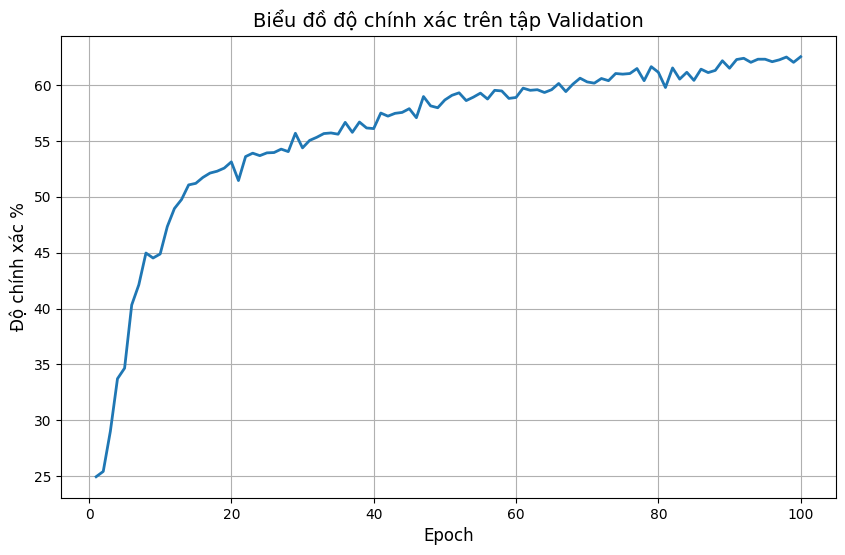

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc CSV
df = pd.read_csv(
    "/kaggle/input/datasets/trgiahuy/wandb-val-acc/wandb_val_acc.csv"
)

# Epoch thật
df["Epoch"] = df["Step"] / 3

# Lấy cột accuracy
acc_col = [c for c in df.columns if "Val Accuracy" in c and "__" not in c][0]

# Vẽ
plt.figure(figsize=(10,6))

plt.plot(
    df["Epoch"],
    df[acc_col],
    linewidth=2
)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Độ chính xác %", fontsize=12)

plt.title("Biểu đồ độ chính xác trên tập Validation", fontsize=14)

plt.grid(True)

plt.show()

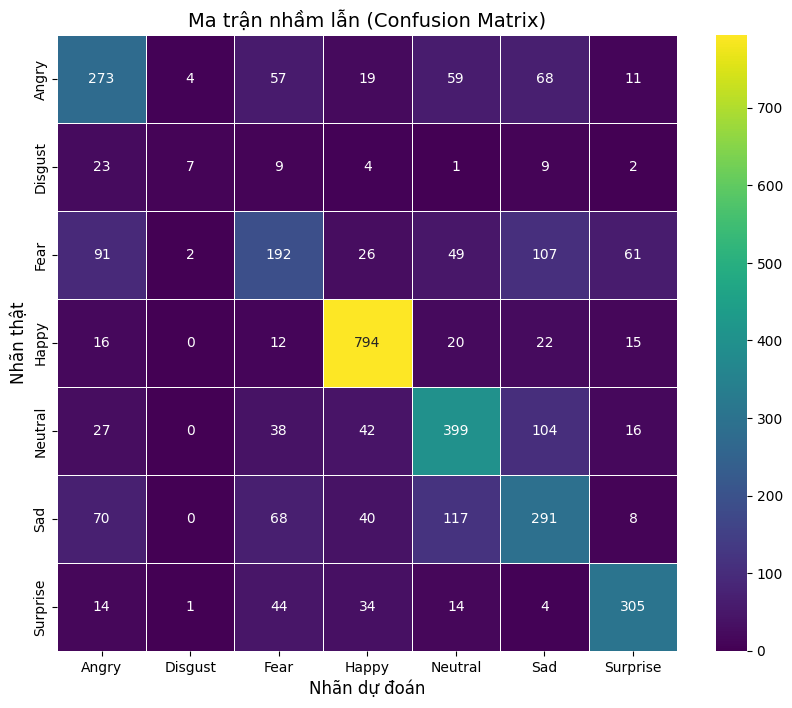

In [13]:
import seaborn as sns

# Đọc CSV confusion matrix
df = pd.read_csv(
    "/kaggle/input/datasets/trgiahuy/wandb-confusion-matrix/wandb_confusion_matrix.csv"
)

# Pivot thành matrix
cm = df.pivot(
    index="Actual",
    columns="Predicted",
    values="nPredictions"
).fillna(0)

# Vẽ heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='.0f',
    cmap='viridis',
    linewidths=0.5,
    linecolor='white'
)

plt.xlabel("Nhãn dự đoán", fontsize=12)
plt.ylabel("Nhãn thật", fontsize=12)

plt.title("Ma trận nhầm lẫn (Confusion Matrix)", fontsize=14)

plt.show()